In [ ]:
# Cell 1: imports, file paths, and basic settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Plot settings
%matplotlib inline
plt.style.use('default')
sns.set_context("talk")

# Adjust below file paths if your filenames differ
bene = pd.read_csv("Train_Beneficiarydata-1542865627584.csv")
inp = pd.read_csv("Train_Inpatientdata-1542865627584.csv")
# Added on_bad_lines='skip' to handle malformed rows in the outpatient data file
outp = pd.read_csv("Train_Outpatientdata-1542865627584.csv", on_bad_lines='skip')
labels = pd.read_csv("Train-1542865627584.csv")

In [ ]:
# Cell 2: Load datasets and inspect columns, dtypes, and sample rows

# Print shapes and first rows to understand granularity
datasets = {"beneficiary": bene, "inpatient": inp, "outpatient": outp, "labels": labels}
for name, df in datasets.items():
    if df is None:
        continue
    print(f"\n=== {name.upper()} ===")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist()[:40])
    print("dtypes (sample):\n", df.dtypes.head(10))
    display(df.head(2))

# Identify likely join keys
print("\nPossible join keys (look for common columns):")
common_cols = set.intersection(*(set(df.columns) for df in datasets.values() if df is not None))
print("Common columns across all loaded files:", common_cols)
print("Look for Provider and BeneID columns:")
for name, df in datasets.items():
    if df is None: continue
    for key in ["Provider", "BeneID", "BENE_ID", "BENEFICIARY_ID", "Bene_ID"]:
        if key in df.columns:
            print(f" -> {key} found in {name}")



=== BENEFICIARY ===
shape: (138556, 25)
columns: ['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']
dtypes (sample):
 BeneID                   object
DOB                      object
DOD                      object
Gender                    int64
Race                      int64
RenalDiseaseIndicator    object
State                     int64
County                    int64
NoOfMonths_PartACov       int64
NoOfMonths_PartBCov       int64
dtype: object


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50



=== INPATIENT ===
shape: (40474, 30)
columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6']
dtypes (sample):
 BeneID                    object
ClaimID                   object
ClaimStartDt              object
ClaimEndDt                object
Provider                  object
InscClaimAmtReimbursed     int64
AttendingPhysician        object
OperatingPhysician        object
OtherPhysician            object
AdmissionDt               object
dt

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN



=== OUTPATIENT ===
shape: (477187, 27)
columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode']
dtypes (sample):
 BeneID                    object
ClaimID                   object
ClaimStartDt              object
ClaimEndDt                object
Provider                  object
InscClaimAmtReimbursed     int64
AttendingPhysician        object
OperatingPhysician        object
OtherPhysician            object
ClmDiagnosisCode_1        object
dtype: object


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79380



=== LABELS ===
shape: (5410, 2)
columns: ['Provider', 'PotentialFraud']
dtypes (sample):
 Provider          object
PotentialFraud    object
dtype: object


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes



Possible join keys (look for common columns):
Common columns across all loaded files: set()
Look for Provider and BeneID columns:
 -> BeneID found in beneficiary
 -> Provider found in inpatient
 -> BeneID found in inpatient
 -> Provider found in outpatient
 -> BeneID found in outpatient
 -> Provider found in labels


In [ ]:
# Cell 3: Data quality checks - missing values, duplicates, unique counts
def data_profile(df, name):
    print(f"\n--- Profile: {name} ---")
    print("rows:", df.shape[0], "cols:", df.shape[1])
    missing = df.isnull().mean().sort_values(ascending=False)
    print("Top columns by missing % (show top 10):")
    display(missing.head(10))
    # Duplicates on likely primary keys
    if "BeneID" in df.columns:
        print("Unique BeneID:", df["BeneID"].nunique())
    if "Provider" in df.columns:
        print("Unique Provider:", df["Provider"].nunique())
    # Show a few rows with missingness
    display(df[df.isnull().any(axis=1)].head(3))

for name, df in datasets.items():
    if df is None: continue
    data_profile(df, name)

# Check label distribution
if labels is not None and "Fraud" in labels.columns:
    print("\nLabel distribution (provider-level):")
    print(labels["Fraud"].value_counts(dropna=False))



--- Profile: beneficiary ---
rows: 138556 cols: 25
Top columns by missing % (show top 10):


,0
DOD,0.989744
BeneID,0.000000
DOB,0.000000
Gender,0.000000
Race,0.000000
RenalDiseaseIndicator,0.000000
State,0.000000
County,0.000000
NoOfMonths_PartACov,0.000000
NoOfMonths_PartBCov,0.000000


Unique BeneID: 138556


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40



--- Profile: inpatient ---
rows: 40474 cols: 30
Top columns by missing % (show top 10):


...

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN



--- Profile: labels ---
rows: 5410 cols: 2
Top columns by missing % (show top 10):


,0
Provider,0.0
PotentialFraud,0.0


Unique Provider: 5410


,Provider,PotentialFraud


Beneficiary dataset EDA
Possible age cols: []
Possible gender cols: ['Gender']


,count
Gender,
2,79106
1,59450


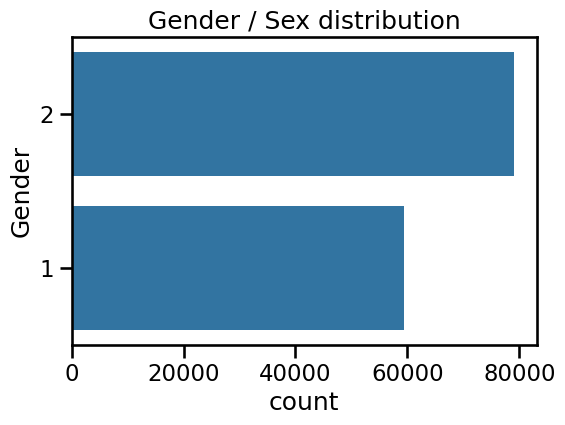

Chronic / condition-like columns (sample): ['ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis']


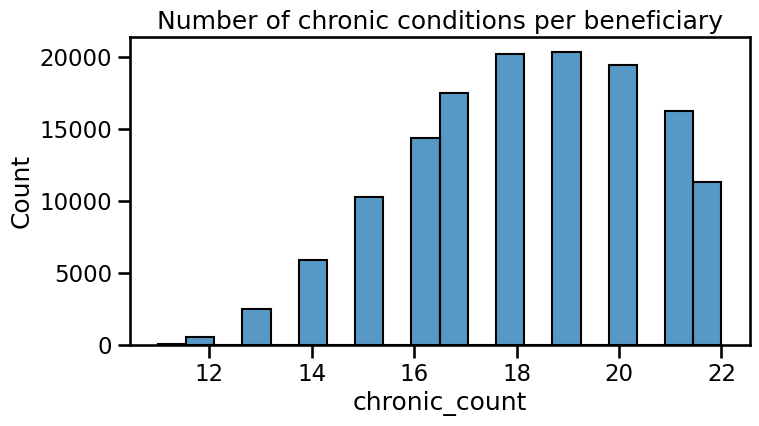

In [ ]:
# Cell 4: Beneficiary EDA — distributions and outliers
if bene is not None:
    print("Beneficiary dataset EDA")
    # Common beneficiary columns: Age, Gender, ChronicCond, CoverageMonths, etc.
    possible_age_cols = [c for c in bene.columns if c.lower().startswith("age")]
    possible_gender_cols = [c for c in bene.columns if c.lower().startswith("sex") or c.lower().startswith("gender")]
    print("Possible age cols:", possible_age_cols)
    print("Possible gender cols:", possible_gender_cols)

    # Age distribution (if present)
    if possible_age_cols:
        age_col = possible_age_cols[0]
        plt.figure(figsize=(8,4))
        sns.histplot(bene[age_col].dropna(), bins=30)
        plt.title(f"Beneficiary age distribution ({age_col})")
        plt.show()

    # Gender breakdown (if present)
    if possible_gender_cols:
        gcol = possible_gender_cols[0]
        display(bene[gcol].value_counts(dropna=False))
        plt.figure(figsize=(6,4))
        sns.countplot(y=gcol, data=bene, order=bene[gcol].value_counts().index)
        plt.title("Gender / Sex distribution")
        plt.show()

    # Chronic conditions — look for columns containing 'chronic' or 'cond'
    chronic_cols = [c for c in bene.columns if "chronic" in c.lower() or "cond" in c.lower()]
    print("Chronic / condition-like columns (sample):", chronic_cols[:10])
    if chronic_cols:
        # sum of chronic conditions per beneficiary (if binary encoded)
        try:
            bene["chronic_count"] = bene[chronic_cols].sum(axis=1)
            plt.figure(figsize=(8,4))
            sns.histplot(bene["chronic_count"], bins=20)
            plt.title("Number of chronic conditions per beneficiary")
            plt.show()
        except Exception as e:
            print("Could not compute chronic_count:", e)
else:
    print("No beneficiary data loaded.")


Inpatient date columns detected: ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt']
Outpatient date columns detected: ['ClaimStartDt', 'ClaimEndDt']
Possible claim amount columns: ['ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'DischargeDt']


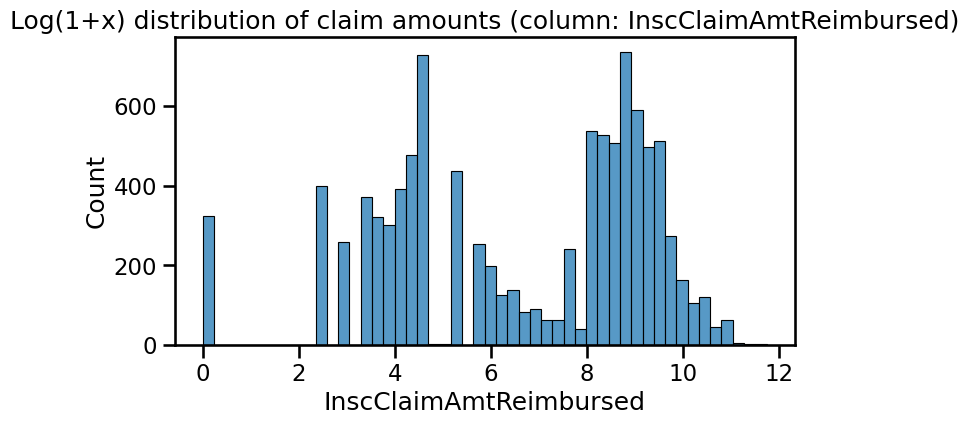

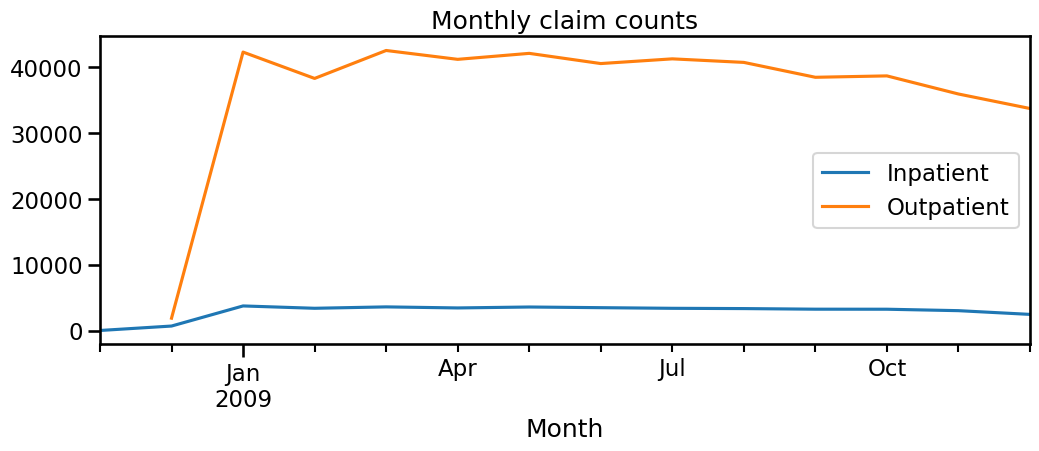

In [ ]:
# Cell 5: Claims EDA — amounts, counts, temporal patterns
def parse_dates(df):
    date_cols = [c for c in df.columns if "date" in c.lower() or "dt" in c.lower()]
    for c in date_cols:
        try:
            df[c] = pd.to_datetime(df[c], errors="coerce")
        except Exception:
            pass
    return df, date_cols

# Preprocess inpatient/outpatient for date columns
if inp is not None:
    inp, inp_date_cols = parse_dates(inp)
else:
    inp_date_cols = []
if outp is not None:
    outp, outp_date_cols = parse_dates(outp)
else:
    outp_date_cols = []

print("Inpatient date columns detected:", inp_date_cols)
print("Outpatient date columns detected:", outp_date_cols)

# Common claim amount columns
possible_amount_cols = []
for df in [inp, outp]:
    if df is None: continue
    for c in df.columns:
        if any(k in c.lower() for k in ["amount","claim","paid","amt","charge"]):
            possible_amount_cols.append(c)
possible_amount_cols = list(dict.fromkeys(possible_amount_cols))
print("Possible claim amount columns:", possible_amount_cols[:10])

# Plot claim amount distribution (combine if necessary)
amount_col = None
for c in possible_amount_cols:
    # pick first reasonable numeric column
    if inp is not None and c in inp.columns and np.issubdtype(inp[c].dtype, np.number):
        amount_col = c; break
    if outp is not None and c in outp.columns and np.issubdtype(outp[c].dtype, np.number):
        amount_col = c; break

if amount_col:
    plt.figure(figsize=(8,4))
    # combine sample of amounts from both datasets to show overall distribution
    samples = []
    if inp is not None and amount_col in inp.columns: samples.append(inp[amount_col].dropna().sample(min(5000, inp.shape[0])))
    if outp is not None and amount_col in outp.columns: samples.append(outp[amount_col].dropna().sample(min(5000, outp.shape[0])))
    if samples:
        combined = pd.concat(samples, ignore_index=True)
        sns.histplot(np.log1p(combined), bins=50)  # log scale to show heavy tails
        plt.title(f"Log(1+x) distribution of claim amounts (column: {amount_col})")
        plt.show()
else:
    print("No numeric claim amount column found automatically. Inspect columns manually:", possible_amount_cols)

# Temporal claim trends (monthly) if date present
date_col = inp_date_cols[0] if inp_date_cols else (outp_date_cols[0] if outp_date_cols else None)
if date_col:
    # combine inpatient and outpatient into small timeseries
    def timeseries_from(df, name):
        if df is None or date_col not in df.columns: return None
        ts = df.groupby(df[date_col].dt.to_period("M")).size().rename(name)
        return ts
    ts_in = timeseries_from(inp, "inpatient_claim_count")
    ts_out = timeseries_from(outp, "outpatient_claim_count")
    if ts_in is not None or ts_out is not None:
        plt.figure(figsize=(12,4))
        if ts_in is not None: ts_in.astype(int).plot(label="Inpatient")
        if ts_out is not None: ts_out.astype(int).plot(label="Outpatient")
        plt.legend(); plt.title("Monthly claim counts"); plt.xlabel("Month"); plt.show()
else:
    print("No claim date column detected for temporal trends.")



Provider summary head:


,Provider,claims_count_in,in_mean_amount,in_sum_amount,claims_count_out,out_mean_amount,out_sum_amount,PotentialFraud,Fraud,Fraud_bin
0,PRV51001,5.0,19400.000000,97000.0,19.0,381.052632,7240.0,No,No,0
1,PRV51003,62.0,9241.935484,573000.0,64.0,396.406250,25370.0,Yes,Yes,1
2,PRV51004,0.0,0.000000,0.0,133.0,354.887218,47200.0,No,No,0
3,PRV51005,0.0,0.000000,0.0,1051.0,243.054234,255450.0,Yes,Yes,1
4,PRV51007,3.0,6333.333333,19000.0,57.0,141.929825,8090.0,No,No,0


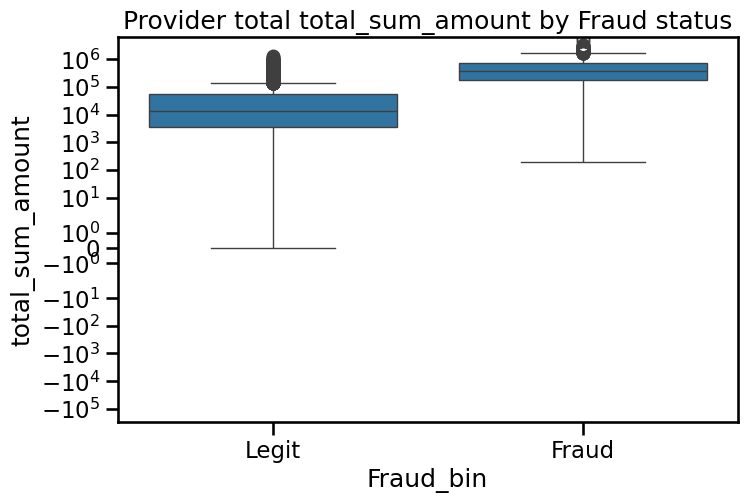

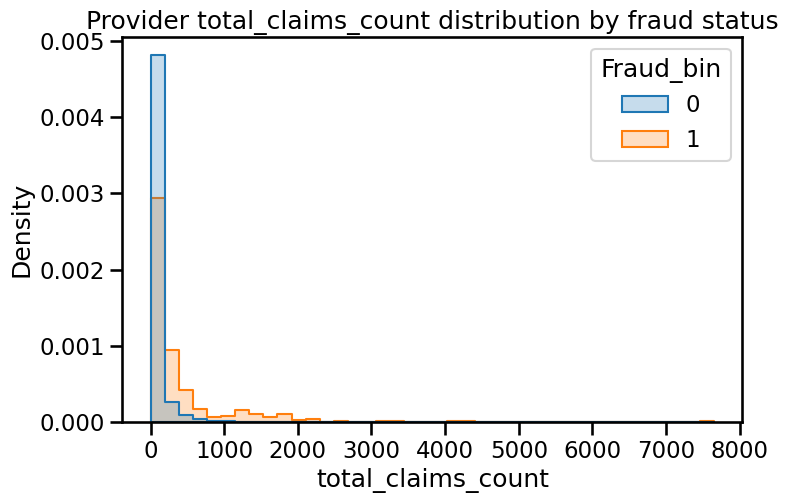

Group means by fraud:


claims_count_in        in_mean_amount               in_sum_amount  \
                     mean median           mean       median           mean   
Fraud_bin                                                                     
0                3.494065    0.0    3375.970908     0.000000   34181.029472   
1               46.249012   24.0    9605.429866  9987.595129  476854.762846   

                    claims_count_out        out_mean_amount              \
             median             mean median            mean      median   
Fraud_bin                                                                 
0               0.0        61.899509   23.0      261.687563  247.341365   
1          265500.0       345.347826   88.0      465.765956  274.595417   

          out_sum_amount          Fraud_bin        total_sum_amount            \
                    mean   median      mean median             mean    median   
Fraud_bin                                                                       
0           17640.114613   6165.0       0.0    0.0     51821.144085   14025.0   
1           99091.462451  27595.0       1.0    1.0    575946.225296  362425.0   

          total_claims_count         
                        mean median  
Fraud_bin                            
0                  65.393573   25.0  
1                 391.596838  147.0

In [ ]:
# Cell 6: Compare fraud vs legit providers (requires labels)
if labels is None:
    print("Labels not loaded. Cannot compare fraud vs legitimate.")
else:
    # Ensure label provider key matches provider column in claims
    # Try to detect Provider column naming inconsistencies
    provider_col = None
    for df in [inp, outp, bene]:
        if df is None: continue
        for c in df.columns:
            if c.lower() == "provider":
                provider_col = "Provider"
                break
    # Merge provider-level labels with a summary of provider activity (counts & avg amount)
    # create quick provider summaries from inpatient/outpatient
    def provider_summary_from(df, prefix):
        if df is None or "Provider" not in df.columns:
            return pd.DataFrame()
        # count claims and mean amount if amount_col exists
        summary = df.groupby("Provider").agg(
            claims_count = ("Provider","size")
        )
        # attempt mean claim amount
        for c in df.columns:
            if any(k in c.lower() for k in ["amount","paid","charge","claim","amt"]):
                if np.issubdtype(df[c].dtype, np.number):
                    summary[f"{prefix}_mean_amount"] = df.groupby("Provider")[c].mean()
                    summary[f"{prefix}_sum_amount"] = df.groupby("Provider")[c].sum()
                    break
        return summary

    s_in = provider_summary_from(inp, "in")
    s_out = provider_summary_from(outp, "out")
    prov_summ = s_in.join(s_out, how="outer", lsuffix='_in', rsuffix='_out').fillna(0)
    prov_summ = prov_summ.reset_index().rename(columns={"index":"Provider"})

    # join with labels
    p_labels = labels.copy()
    if "Provider" not in p_labels.columns:
        # try common provider id column alternatives
        for alt in p_labels.columns:
            if alt.lower().find("prov") >= 0:
                p_labels = p_labels.rename(columns={alt:"Provider"})
                break

    prov_summ = prov_summ.merge(p_labels[["Provider","PotentialFraud"]], on="Provider", how="left")
    prov_summ["Fraud"] = prov_summ["PotentialFraud"].fillna("No")  # treat missing as not labeled fraudulent

    # Convert Fraud to binary if necessary
    if prov_summ["Fraud"].dtype == object:
        prov_summ["Fraud_bin"] = prov_summ["Fraud"].map(lambda x: 1 if str(x).lower() in ["yes","y","1","true","fraud"] else 0)
    else:
        prov_summ["Fraud_bin"] = prov_summ["Fraud"].astype(int)

    # Compare distributions
    print("\nProvider summary head:")
    display(prov_summ.head())

    # Boxplots / distribution of total claims by fraud status
    # Use the combined sum of claims if both exist, otherwise use one of them
    if 'in_sum_amount' in prov_summ.columns and 'out_sum_amount' in prov_summ.columns:
        prov_summ['total_sum_amount'] = prov_summ['in_sum_amount'] + prov_summ['out_sum_amount']
        amount_col_to_plot = 'total_sum_amount'
    elif 'in_sum_amount' in prov_summ.columns:
        amount_col_to_plot = 'in_sum_amount'
    elif 'out_sum_amount' in prov_summ.columns:
        amount_col_to_plot = 'out_sum_amount'
    else:
        amount_col_to_plot = None

    if amount_col_to_plot:
        plt.figure(figsize=(8,5))
        sns.boxplot(x="Fraud_bin", y=amount_col_to_plot, data=prov_summ)
        plt.xticks([0,1], ["Legit","Fraud"])
        plt.yscale("symlog")  # handle wide ranges
        plt.title(f"Provider total {amount_col_to_plot} by Fraud status")
        plt.show()

    # Compare claim counts
    # Use the combined sum of claims_count if both exist, otherwise use one of them
    if 'claims_count_in' in prov_summ.columns and 'claims_count_out' in prov_summ.columns:
        prov_summ['total_claims_count'] = prov_summ['claims_count_in'] + prov_summ['claims_count_out']
        claims_count_to_plot = 'total_claims_count'
    elif 'claims_count_in' in prov_summ.columns:
        claims_count_to_plot = 'claims_count_in'
    elif 'claims_count_out' in prov_summ.columns:
        claims_count_to_plot = 'claims_count_out'
    else:
        claims_count_to_plot = None

    if claims_count_to_plot:
        plt.figure(figsize=(8,5))
        sns.histplot(data=prov_summ, x=claims_count_to_plot, hue="Fraud_bin", element="step", stat="density", common_norm=False, bins=40)
        plt.title(f"Provider {claims_count_to_plot} distribution by fraud status")
        plt.show()

    # Mean summary statistics
    print("Group means by fraud:")
    # Select only numeric columns for aggregation to avoid TypeError
    numeric_cols = prov_summ.select_dtypes(include=np.number).columns.tolist()
    display(prov_summ.groupby("Fraud_bin")[numeric_cols].agg(["mean","median"]).head())

In [ ]:
# Cell 7: Aggregation to provider-level with multiple summary statistics
# Aim: produce a single provider-level dataset to use as modeling unit

# Basic helper to aggregate a claim table to provider-level
def aggregate_claims(df, prefix):
    if df is None or "Provider" not in df.columns:
        return pd.DataFrame()
    agg = {}
    # numeric columns: mean, std, sum, median
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # exclude ID columns that are numeric but not features
    exclude = ["BeneID", "Provider", "BENE_ID", "ID"]
    num_cols = [c for c in num_cols if c not in exclude]
    for c in num_cols:
        agg[f"{prefix}_{c}_mean"] = (c, "mean")
        agg[f"{prefix}_{c}_std"] = (c, "std")
        agg[f"{prefix}_{c}_sum"] = (c, "sum")
        agg[f"{prefix}_{c}_median"] = (c, "median")
    # counts and unique beneficiaries
    agg["claims_count"] = ("Provider", "size")
    if "BeneID" in df.columns:
        agg["unique_benes"] = ("BeneID", "nunique")
    # build named aggregation dictionary
    named_agg = {}
    for k, v in agg.items():
        if isinstance(v, tuple):
            named_agg[k] = pd.NamedAgg(column=v[0], aggfunc=v[1])
        else:
            named_agg[k] = v

    grouped = df.groupby("Provider").agg(**named_agg)
    # Add ratio features: avg claims per beneficiary
    if "unique_benes" in grouped.columns and "claims_count" in grouped.columns:
        grouped["claims_per_bene"] = grouped["claims_count"] / (grouped["unique_benes"].replace(0, np.nan))
    return grouped

agg_in = aggregate_claims(inp, "in") if inp is not None else pd.DataFrame()
agg_out = aggregate_claims(outp, "out") if outp is not None else pd.DataFrame()

# Combine aggregates
provider_level = pd.concat([agg_in, agg_out], axis=1).fillna(0)
provider_level.reset_index(inplace=True)
# merge beneficiary aggregates: e.g., number of beneficiaries per provider (by joining claim tables)
if bene is not None and "BeneID" in bene.columns:
    # create a mapping from BeneID to Provider via claims (if claims have BeneID->Provider)
    # We'll approximate: find for each provider how many unique beneficiaries exist across claims
    providers_from_claims = pd.DataFrame()
    if inp is not None and "Provider" in inp.columns and "BeneID" in inp.columns:
        providers_from_claims = inp[["Provider","BeneID"]]
    if outp is not None and "Provider" in outp.columns and "BeneID" in outp.columns:
        providers_from_claims = pd.concat([providers_from_claims, outp[["Provider","BeneID"]]], ignore_index=True)
    if not providers_from_claims.empty:
        bene_counts = providers_from_claims.groupby("Provider")["BeneID"].nunique().rename("num_unique_benes")
        provider_level = provider_level.merge(bene_counts.reset_index(), on="Provider", how="left").fillna(0)

# Merge labels
if labels is not None:
    lab = labels.copy()
    if "Provider" not in lab.columns:
        for c in lab.columns:
            if "prov" in c.lower():
                lab = lab.rename(columns={c: "Provider"})
                break
    final_provider_df = provider_level.merge(lab, on="Provider", how="left")
else:
    final_provider_df = provider_level

print("Provider-level dataset created with shape:", final_provider_df.shape)
display(final_provider_df.head())
# Save for downstream use
final_provider_df.to_csv("final_provider_dataset_from_EDA.csv", index=False)
print("Saved aggregated provider dataset to final_provider_dataset_from_EDA.csv")


Provider-level dataset created with shape: (5392, 73)


,Provider,in_InscClaimAmtReimbursed_mean,in_InscClaimAmtReimbursed_std,in_InscClaimAmtReimbursed_sum,in_InscClaimAmtReimbursed_median,in_DeductibleAmtPaid_mean,in_DeductibleAmtPaid_std,in_DeductibleAmtPaid_sum,in_DeductibleAmtPaid_median,in_ClmProcedureCode_1_mean,in_ClmProcedureCode_1_std,in_ClmProcedureCode_1_sum,in_ClmProcedureCode_1_median,in_ClmProcedureCode_2_mean,in_ClmProcedureCode_2_std,in_ClmProcedureCode_2_sum,in_ClmProcedureCode_2_median,in_ClmProcedureCode_3_mean,in_ClmProcedureCode_3_std,in_ClmProcedureCode_3_sum,in_ClmProcedureCode_3_median,in_ClmProcedureCode_4_mean,in_ClmProcedureCode_4_std,in_ClmProcedureCode_4_sum,in_ClmProcedureCode_4_median,in_ClmProcedureCode_5_mean,in_ClmProcedureCode_5_std,in_ClmProcedureCode_5_sum,in_ClmProcedureCode_5_median,in_ClmProcedureCode_6_mean,in_ClmProcedureCode_6_std,in_ClmProcedureCode_6_sum,in_ClmProcedureCode_6_median,claims_count,unique_benes,claims_per_bene,out_InscClaimAmtReimbursed_mean,out_InscClaimAmtReimbursed_std,out_InscClaimAmtReimbursed_sum,out_InscClaimAmtReimbursed_median,out_ClmProcedureCode_1_mean,out_ClmProcedureCode_1_std,out_ClmProcedureCode_1_sum,out_ClmProcedureCode_1_median,out_ClmProcedureCode_2_mean,out_ClmProcedureCode_2_std,out_ClmProcedureCode_2_sum,out_ClmProcedureCode_2_median,out_ClmProcedureCode_3_mean,out_ClmProcedureCode_3_std,out_ClmProcedureCode_3_sum,out_ClmProcedureCode_3_median,out_ClmProcedureCode_4_mean,out_ClmProcedureCode_4_std,out_ClmProcedureCode_4_sum,out_ClmProcedureCode_4_median,out_ClmProcedureCode_5_mean,out_ClmProcedureCode_5_std,out_ClmProcedureCode_5_sum,out_ClmProcedureCode_5_median,out_ClmProcedureCode_6_mean,out_ClmProcedureCode_6_std,out_ClmProcedureCode_6_sum,out_ClmProcedureCode_6_median,out_DeductibleAmtPaid_mean,out_DeductibleAmtPaid_std,out_DeductibleAmtPaid_sum,out_DeductibleAmtPaid_median,claims_count,unique_benes,claims_per_bene,num_unique_benes,PotentialFraud
0,PRV51001,19400.000000,18352.111595,97000.0,12000.0,1068.0,0.0,5340.0,1068.0,6090.000000,3633.114642,12180.0,6090.0,2724.000000,0.000000,2724.0,2724.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,1.000000,381.052632,434.381997,7240.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,19.0,18.0,1.055556,23,No
1,PRV51003,9241.935484,8513.606244,573000.0,7000.0,1068.0,0.0,66216.0,1068.0,5460.846154,2826.546354,212973.0,4516.0,3670.333333,1159.648977,33033.0,4019.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62.0,53.0,1.169811,396.406250,725.020782,25370.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.093750,8.750000,70.0,0.0,64.0,60.0,1.066667,111,Yes
2,PRV51007,6333.333333,3511.884584,19000.0,6000.0,1068.0,0.0,3204.0,1068.0,8627.000000,0.000000,8627.0,8627.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,1.000000,141.929825,163.329625,8090.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.052632,6.730583,60.0,0.0,57.0,47.0,1.212766,49,No
3,PRV51008,12500.000000,12020.815280,25000.0,12500.0,1068.0,0.0,2136.0,1068.0,4556.500000,6219.004141,9113.0,4556.5,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1.000000,240.750000,391.167795,9630.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.500000,19.993589,180.0,0.0,40.0,33.0,1.212121,35,No
4,PRV51011,5000.000000,0.000000,5000.0,5000.0,1068.0,0.0,1068.0,1068.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.000000,188.035714,288.944283,10530.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.285714,18.572428,240.0,0.0,56.0,51.0,1.098039,52,No


Saved aggregated provider dataset to final_provider_dataset_from_EDA.csv


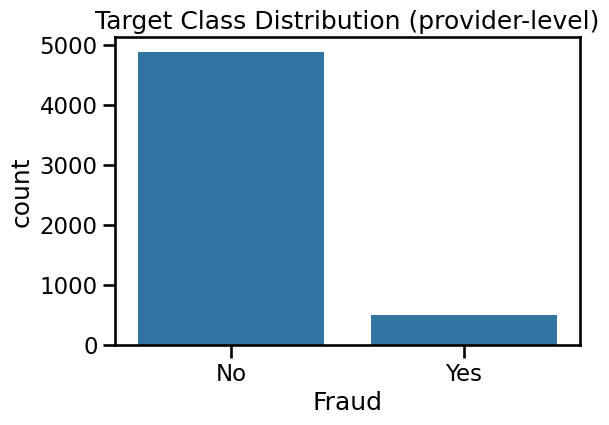

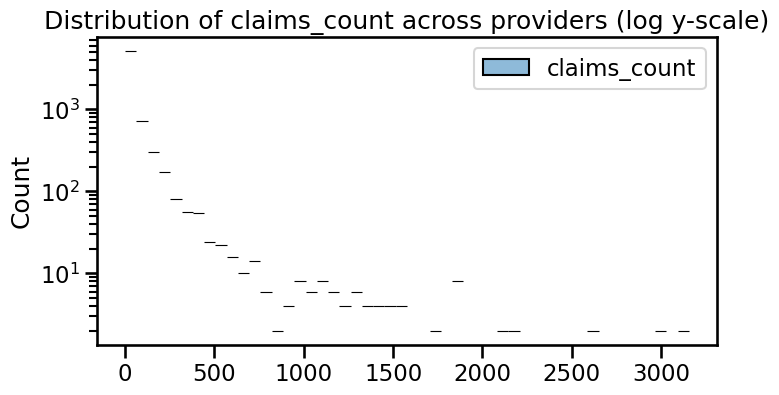

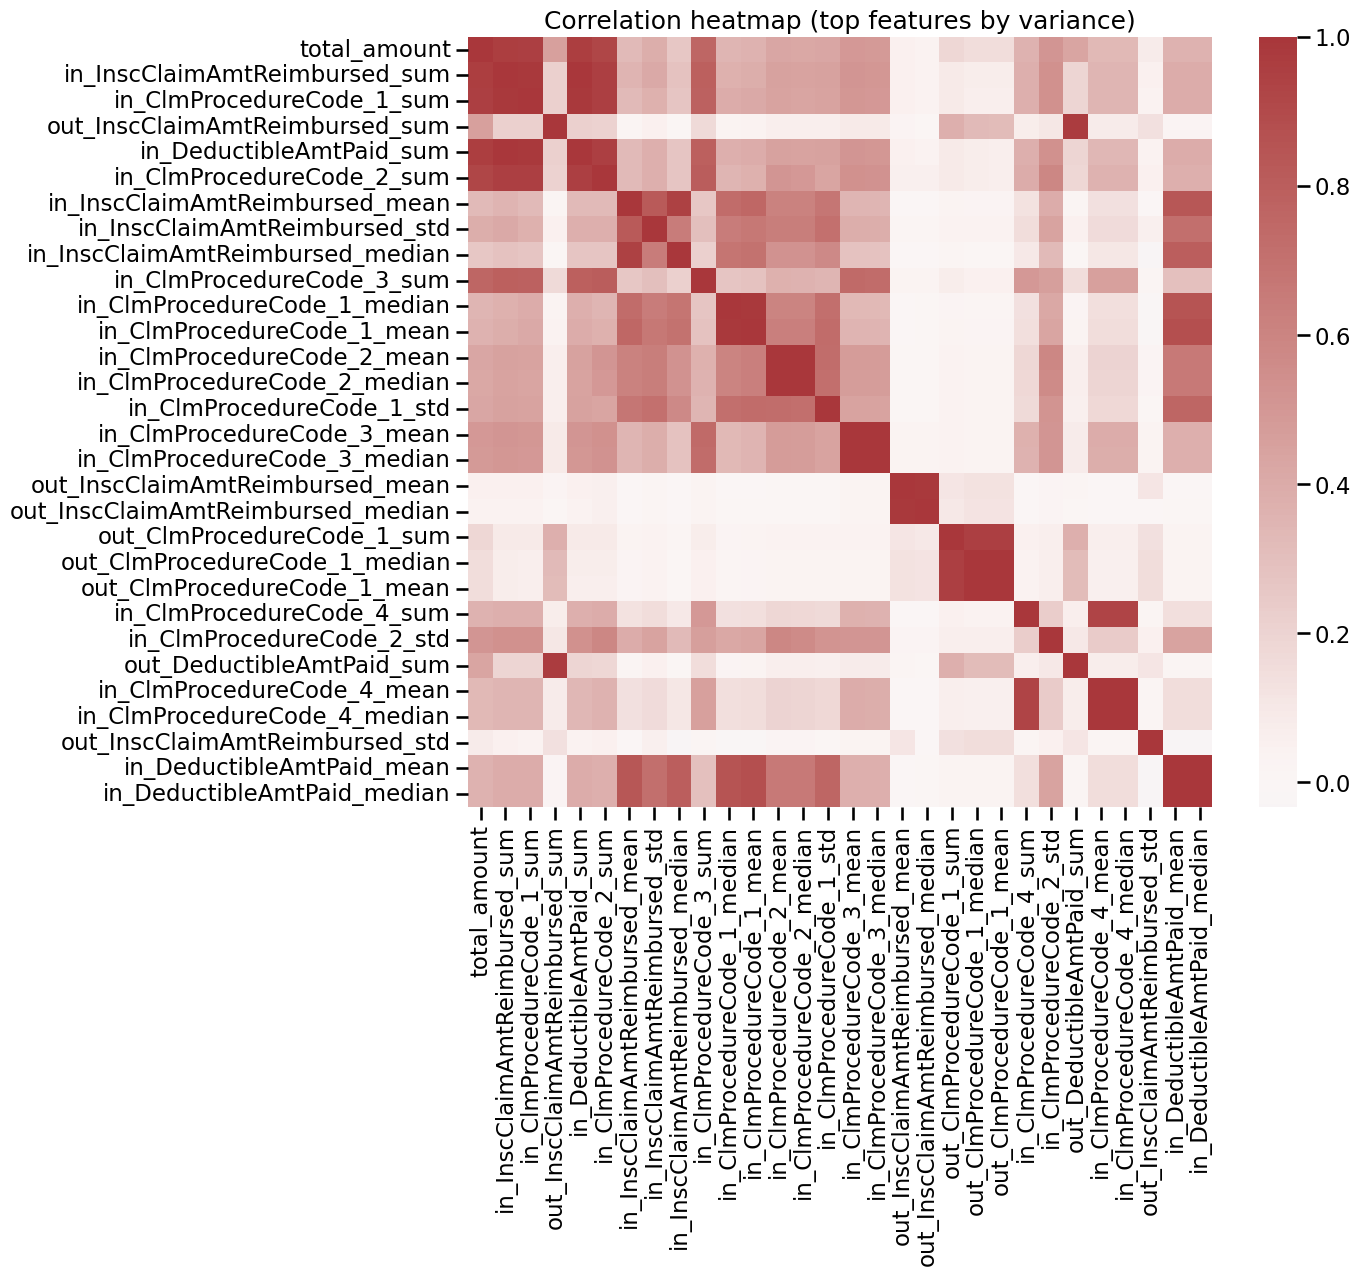

In [ ]:
# Cell 8: Core visualizations
# 1) Target class distribution
if "Fraud" in final_provider_df.columns or "Fraud_bin" in final_provider_df.columns:
    col = "Fraud" if "Fraud" in final_provider_df.columns else "Fraud_bin"
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=final_provider_df)
    plt.title("Target Class Distribution (provider-level)")
    plt.show()
else:
    print("No Fraud label in provider-level dataset to plot distribution.")

# 2) Provider-level summary: claims_count distribution
if "claims_count" in final_provider_df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(final_provider_df["claims_count"].replace(0,np.nan).dropna(), bins=50, log_scale=(False, True))
    plt.title("Distribution of claims_count across providers (log y-scale)")
    plt.show()

# 3) Correlation heatmap for numeric features (sample top 30 numeric cols)
num_cols = final_provider_df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr = final_provider_df[num_cols].corr().abs()
    # limit to top features by variance to keep heatmap readable
    top_feats = final_provider_df[num_cols].var().sort_values(ascending=False).head(30).index.tolist()
    plt.figure(figsize=(12,10))
    sns.heatmap(final_provider_df[top_feats].corr(), cmap="vlag", center=0, annot=False)
    plt.title("Correlation heatmap (top features by variance)")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")


In [ ]:
# Cell 9: Geographic and temporal patterns (optional, runs only if relevant columns exist)

# Geographic: look for state/zip/city columns
geo_cols = [c for c in final_provider_df.columns if any(k in c.lower() for k in ["state","zip","city","county"])]
print("Geographic-like columns detected:", geo_cols)

if geo_cols:
    # if state present, show fraud rate by state
    state_col = next((c for c in geo_cols if "state" in c.lower()), None)
    if state_col and state_col in final_provider_df.columns and "Fraud_bin" in final_provider_df.columns:
        by_state = final_provider_df.groupby(state_col)["Fraud_bin"].mean().sort_values(ascending=False)
        display(by_state.head(20))
        plt.figure(figsize=(10,5))
        by_state.plot(kind="bar")
        plt.title("Fraud rate by state (provider-level)")
        plt.ylabel("Fraud rate")
        plt.show()
    else:
        print("No usable 'state' column or Fraud_bin missing for geographic summary.")
else:
    print("No geographic columns available.")

# Temporal: if provider-level has time features (e.g., claim_month), show trend of fraud rate over time
time_like_cols = [c for c in final_provider_df.columns if any(k in c.lower() for k in ["month","year","period","date"])]
print("Time-like columns detected in provider-level:", time_like_cols)
if time_like_cols:
    # attempt to aggregate by first time column
    tcol = time_like_cols[0]
    if tcol in final_provider_df.columns and "Fraud_bin" in final_provider_df.columns:
        temp = final_provider_df.groupby(tcol)["Fraud_bin"].mean()
        temp.plot(figsize=(10,4), marker='o')
        plt.title(f"Fraud rate over {tcol}")
        plt.ylabel("Fraud rate")
        plt.show()
    else:
        print("Time-like column found but cannot compute trends (missing Fraud_bin or incompatible types).")
else:
    print("No provider-level time columns detected for temporal pattern plotting.")


Geographic-like columns detected: []
No geographic columns available.
Time-like columns detected in provider-level: []
No provider-level time columns detected for temporal pattern plotting.


Class distribution:
Fraud_bin
0    4886
1     506
Name: count, dtype: int64


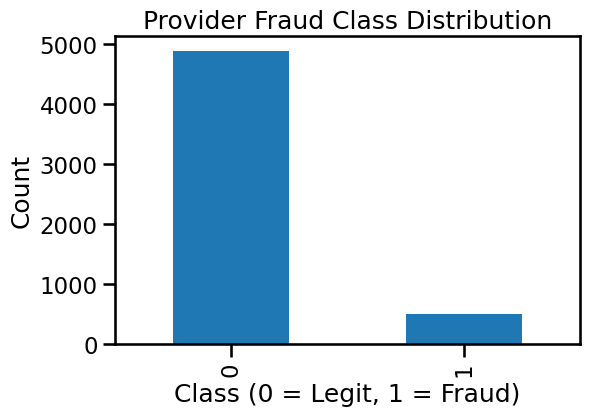

In [55]:
#Cell 10: Check Class Imbalance

# Check distribution of the target class (fraudulent vs legitimate providers)
provider_class_counts = final_provider_df['Fraud_bin'].value_counts()

print("Class distribution:")
print(provider_class_counts)

# Plot distribution
plt.figure(figsize=(6,4))
provider_class_counts.plot(kind='bar')
plt.title("Provider Fraud Class Distribution")
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [58]:
#Cell 11: Train/Test Split (Before Applying Any Balancing Technique)
from sklearn.model_selection import train_test_split

X = final_provider_df.drop(['Fraud_bin', 'Provider', 'PotentialFraud'], axis=1)
y = final_provider_df['Fraud_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))
print("Fraud % in training:", y_train.mean())

Training set size: 4044
Test set size: 1348
Fraud % in training: 0.09396636993076163


In [62]:
#Cell 12: Oversampling Using SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

# Oversample only training set

# First, handle missing values in X_train
imputer = SimpleImputer(strategy='mean') # You can choose 'median' or another strategy
X_train_imputed = imputer.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_imputed, y_train)

print("After SMOTE oversampling:")
print(y_train_sm.value_counts())

After SMOTE oversampling:
Fraud_bin
0    3664
1    3664
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['total_claims_nonzero' 'avg_claim_amount']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [65]:
#Cell 13: Evaluation Metrics Prioritizing Imbalance-Friendly Metrics
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix
)

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"=== {name} ===")
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("PR AUC:", average_precision_score(y_true, y_prob))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\n")

evaluate_model("Logistic Regression (Class Weighted)", y_test, y_pred_lr, y_prob_lr)
evaluate_model("Random Forest (SMOTE)", y_test, y_pred_rf, y_prob_rf)


=== Logistic Regression (Class Weighted) ===
Precision: 0.38028169014084506
Recall: 0.8571428571428571
F1-score: 0.526829268292683
PR AUC: 0.6896781934428383
ROC AUC: 0.8956855791962175

Confusion Matrix:
[[1046  176]
 [  18  108]]


=== Random Forest (SMOTE) ===
Precision: 0.5668789808917197
Recall: 0.7063492063492064
F1-score: 0.6289752650176679
PR AUC: 0.6689816032197848
ROC AUC: 0.9362254176083964

Confusion Matrix:
[[1154   68]
 [  37   89]]




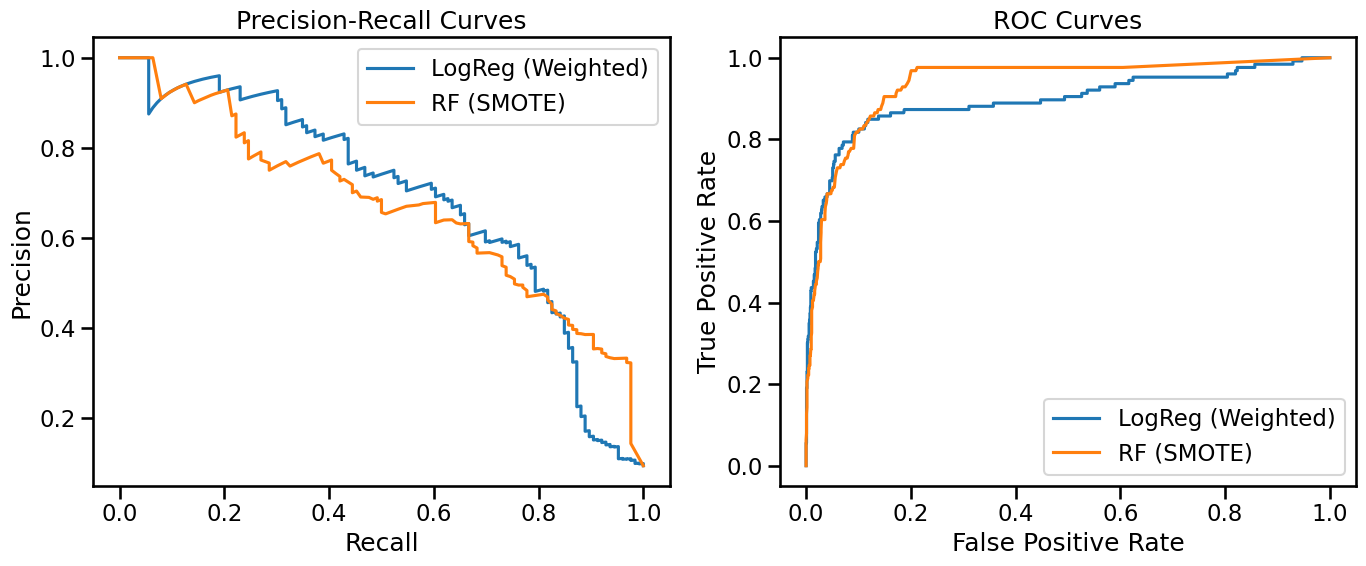

In [66]:
#Cell 14: Precision-Recall Curve & ROC Curve Comparison
from sklearn.metrics import precision_recall_curve, roc_curve

plt.figure(figsize=(14,6))

# --- Precision Recall ---
plt.subplot(1,2,1)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.plot(rec_lr, prec_lr, label="LogReg (Weighted)")
plt.plot(rec_rf, prec_rf, label="RF (SMOTE)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()

# --- ROC ---
plt.subplot(1,2,2)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label="LogReg (Weighted)")
plt.plot(fpr_rf, tpr_rf, label="RF (SMOTE)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.tight_layout()
plt.show()
